# Deep Learning: Assignment #1
## Submission date: 03/12/2025, 23:59.
### Topics:
- Logistic Regression
- Feedforward Neural Networks
- Backpropagation
- Optimization
- Batch Normalization

**Submitted by:**

- **Aisha Abu Dahesh**
- **Yousef Asadi**  


**Assignment Instruction:**

· Submissions are in **pairs only**. Write both names + IDs at the top of the notebook.

· Keep your code **clean, concise, and readable**.

· You may work in your IDE, but you **must** paste the final code back into the **matching notebook cells** and run it there.  


· <font color='red'>Write your textual answers in red.</font>  
(e.g., `<span style="color:red">your answer here</span>`)

· All figures, printed results, and outputs should remain visible in the notebook.  
Run **all cells** before submitting and **do not clear outputs**.

· Use relative paths — **no absolute file paths** pointing to local machines.

· **Important:** Your submission must be entirely your own.  
Any form of plagiarism (including uncredited use of ChatGPT or AI tools) will result in **grade 0** and disciplinary action.


In [1]:
# --- Global Setup ---

# Import Libraries
import torch
import numpy as np
import matplotlib.pyplot as plt
import itertools
import random
import torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import torch.optim as optim
import torch.nn.init as init

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


## Question 1 — From Classic ML to Deep Networks

In this question we embark on a short expedition from classic Machine Learning to Deep Learning.

We will compare the performance of a **multiclass logistic regression** to a **multi-layer perceptron (MLP)** on the **MNIST** dataset.


Start by running this cell which includes relative setup and useful helper functions implemented for you to use.

In [2]:
# --- Define Seed ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# --- Helper Functions To Use ---
def accuracy(logits: torch.Tensor, y: torch.Tensor):
    """Top-1 accuracy for logits [N,C] and labels [N]."""
    return (logits.argmax(dim=1) == y).float().mean().item()

def count_params(obj):
    """
    Count trainable parameters.
    - If obj is (W, b) tuple → counts elements.
    - If obj is a nn.Module → sums requires_grad params.
    """
    if isinstance(obj, tuple) and len(obj) == 2:
        W, b = obj
        return W.numel() + b.numel()
    if isinstance(obj, nn.Module):
        return sum(p.numel() for p in obj.parameters() if p.requires_grad)
    raise TypeError("count_params expects (W,b) or nn.Module.")


@torch.no_grad()
def evaluate_acc(W: torch.Tensor, b: torch.Tensor, loader):
    """Dataset-level accuracy for a linear softmax model parameterized by (W,b)."""
    total_acc, total_n = 0.0, 0
    for xb, yb in loader:
        xb = xb.to(DEVICE).view(xb.size(0), -1)
        yb = yb.to(DEVICE)
        logits = xb @ W + b
        batch_acc = accuracy(logits, yb)
        n = xb.size(0)
        total_acc += batch_acc * n         # weight by batch size
        total_n   += n
    return total_acc / total_n


# Use this function in the training loop for your nn.Module
@torch.no_grad()
def evaluate_module(model: nn.Module, loader):
    model.eval()
    total_acc, total_n = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits = model(xb)
        batch_acc = accuracy(logits, yb)
        n = xb.size(0)
        total_acc += batch_acc * n
        total_n   += n
    return total_acc / total_n

### Load & Preprocess the Data:



We first load the MNIST dataset as provided by `torchvision`. All images are automatically converted to tensors in the range $[0,1]$.


In [3]:
# Load the raw MNIST dataset
transform = transforms.ToTensor()

train_full = datasets.MNIST(root="./data", train=True,  download=True, transform=transform)
test_set   = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

print(f"\n Train set: {len(train_full)} samples  |  Test set: {len(test_set)} samples")


 Train set: 60000 samples  |  Test set: 10000 samples


Implement the following steps:

1. **Split the data:**
   - The MNIST test set is already provided.
   - From the full training set, create an 80/20 split into **train** and **validation** subsets.

2. **Construct `DataLoader` objects:**
   - `train_loader` → use shuffling.
   - `val_loader` → no shuffling.
   - `test_loader` → no shuffling.2.

3. **Print a quick sanity check:**
   - batch shapes `(batch_size = 128, 1, 28, 28)`
   - label range (0–9)

*Example format:*
```python
Batch: torch.Size([128, 1, 28, 28]) torch.Size([128]) | pixel range = (0.0, 1.0)


In [4]:
# TODO: Implement preprocessing
train_size = int(0.8 * len(train_full))
val_size   = len(train_full) - train_size
train_set, val_set = random_split(train_full, [train_size, val_size])
print(f" Training set: {len(train_set)} samples  |  Validation set: {len(val_set)} samples\n")
# Create DataLoaders
BATCH_SIZE = 128
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)
print(f" DataLoaders created with batch size {BATCH_SIZE}\n")
# Example: Fetch a batch and display its shape
example_batch = next(iter(train_loader))
images, labels = example_batch
print(f" Example batch - images shape: {images.shape}, labels shape: {labels.shape}\n")
# Output: Device: cuda
# Train set: 60000 samples  |  Test set: 10000 samples
#  Training set: 48000 samples  |  Validation set: 12000 samples
#  DataLoaders created with batch size 128
#  Example batch - images shape: torch.Size([128, 1, 28, 28]), labels shape: torch.Size([128])

 Training set: 48000 samples  |  Validation set: 12000 samples

 DataLoaders created with batch size 128

 Example batch - images shape: torch.Size([128, 1, 28, 28]), labels shape: torch.Size([128])



###  Multiclass Logistic Regression



In binary logistic regression, we model  
$$
P(y=1 \mid x) = \sigma(w^\top x + b)
$$
where  $\sigma$ is the sigmoid activation function.

For **multiclass** problems, like ours where MNIST is a dataset of images of 10 digits, hence 10 classes, we generalize this idea.

Each class $c \in \{0, \dots, 9\}$ has its own weight vector  $w_c$ and bias  $b_c$.

We stack them into a **weight matrix**  $W \in \mathbb{R}^{d \times C}$
and a **bias vector**  $b \in \mathbb{R}^{C}$.

<br>

Generally speaking, we compute a forward pass by computing:

$$
z_i = W^\top x_i + b
$$

where $W \in \mathbb{R}^{d \times C}$ is the weight matrix and $b \in \mathbb{R}^C$ is the bias vector.

<br>

We then obtain class probabilities via the softmax function:

$$
p_i(c) = \frac{e^{z_i(c)}}{\sum_{k=1}^{C} e^{z_i(k)}}
$$

The model is trained by minimizing the **cross-entropy loss** between the predicted probabilities and the true class labels:

$$
\mathcal{L}(W,b) = -\frac{1}{N} \sum_{i=1}^N \log p_i(y_i)
$$

and the parameters are updated using **gradient descent**:

$$
W \leftarrow W - \eta \, \nabla_W \mathcal{L}, \qquad
b \leftarrow b - \eta \, \nabla_b \mathcal{L}
$$


<br><br>
In this question, you will build a multiclass logistic regression model from scratch, train it using the cross-entropy loss, and optimize it with gradient descent.

<br>

You will then evaluate the model’s performance on the MNIST dataset, and train it on 20 epochs.


In [5]:
def logistic_regression(train_loader, val_loader, epochs=20, lr=0.1, tol=1e-6):
    """
    Train a multiclass logistic regression model using gradient descent.
    - X: [N, d] input features (flattened images)
    - y: [N] class labels in {0,...,9}
    - lr: learning rate
    - max_steps: max number of iterations
    - tol: stop early when gradients converge

    Returns: (W, b)
    """

    # TODO: Implement logistic_regression
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    w = (torch.randn(28*28, 10, device=DEVICE) * 0.01).requires_grad_(True)
    b = (torch.zeros(10, device=DEVICE)).requires_grad_(True)
    
    optimizer = optim.SGD([w, b], lr=lr)
    
    criterion = nn.CrossEntropyLoss()
    
    for epoch in range(epochs):
        epoch_loss = []
        
        for i, (xb, yb) in enumerate(train_loader):
            xb = xb.to(DEVICE).view(xb.size(0), -1)
            yb = yb.to(DEVICE)
            
            logits = xb @ w + b
            loss = criterion(logits, yb)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            if i == len(train_loader) - 1:
                with torch.no_grad():
                    grad_w_norm = w.grad.norm()
                    grad_b_norm = b.grad.norm()
                    total_grad_norm = torch.sqrt(grad_w_norm**2 + grad_b_norm**2)
                
                if total_grad_norm < tol:
                    print(f"Converged at epoch {epoch+1} with gradient norm {total_grad_norm:.4e}")
                    return w, b
            
            
            epoch_loss.append(loss.item()) 

        val_acc = evaluate_acc(w, b, val_loader)
        print(f"Epoch {epoch+1}/{epochs}, Val Acc: {val_acc:.4f}, Loss: {epoch_loss[-1]:.4f}, grad_norm: {total_grad_norm:.4e}")
        
    return w, b

Now run the next cell to evaluate your multiclass logistic regression.

We use the `evaluate_acc` helper function to evaluate.


In [18]:
# TODO: Run
W, b = logistic_regression(train_loader, val_loader, epochs=20, lr=0.1)

model = (W, b)

# Evaluate
val_acc  = evaluate_acc(W, b, val_loader)
test_acc = evaluate_acc(W, b, test_loader)

print(f"\nNumber of Parameters: {count_params(model):,}")
print(f"Val. acc.: {val_acc:.4f}")
print(f"Test acc.: {test_acc:.4f}")

Epoch 1/20, Val Acc: 0.8856, Loss: 0.4602, grad_norm: 3.8657e-01
Epoch 2/20, Val Acc: 0.8953, Loss: 0.3544, grad_norm: 2.8642e-01
Epoch 3/20, Val Acc: 0.9008, Loss: 0.4153, grad_norm: 3.9113e-01
Epoch 4/20, Val Acc: 0.9039, Loss: 0.3377, grad_norm: 3.8946e-01
Epoch 5/20, Val Acc: 0.9046, Loss: 0.3427, grad_norm: 3.1939e-01
Epoch 6/20, Val Acc: 0.9070, Loss: 0.2450, grad_norm: 2.5217e-01
Epoch 7/20, Val Acc: 0.9086, Loss: 0.3485, grad_norm: 2.7076e-01
Epoch 8/20, Val Acc: 0.9092, Loss: 0.2820, grad_norm: 3.0890e-01
Epoch 9/20, Val Acc: 0.9093, Loss: 0.1971, grad_norm: 1.9631e-01
Epoch 10/20, Val Acc: 0.9100, Loss: 0.1948, grad_norm: 2.3912e-01
Epoch 11/20, Val Acc: 0.9115, Loss: 0.3420, grad_norm: 2.7023e-01
Epoch 12/20, Val Acc: 0.9123, Loss: 0.2867, grad_norm: 3.0010e-01
Epoch 13/20, Val Acc: 0.9122, Loss: 0.3670, grad_norm: 3.3169e-01
Epoch 14/20, Val Acc: 0.9140, Loss: 0.2688, grad_norm: 3.1260e-01
Epoch 15/20, Val Acc: 0.9142, Loss: 0.3090, grad_norm: 3.4803e-01
Epoch 16/20, Val Ac

Answer the following questions:

1. Is a *logistic regression* a sufficient model for this task?  
   What **constraints** does this model impose on the decision boundaries and on what it can “represent”?  
   What **modification** might help address these constraints?


2. Give two examples of incorrectly classified digits. Include the image of the misclassified digit,
the predicted class and the actual class in your write up

</br>

<font color='red'>1. the logistic regression model worked well on MNIST but its not sufficient for this task, we got 92% accuracy while more complex models such as multi layer percepteron or CNNs can get more than 98% easily, moreover we are working with images so linear classsifiers such as logistics regression are not sufficient because of their limited representational power, so the constraints that the model impose on the decision boundries is the linearity, in other words each class is separated from the others by a hyperplane in a 784 dimensional space, so hand written digits are not linearly separable.

modification: we can stack hidden layers with non linear activation to learn non linear decision boundaries, also it can learn meaningful features auch as curves, edges and so it has more representational power.</font>

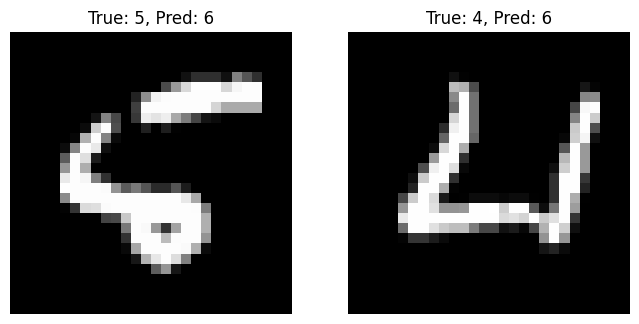

In [19]:
"""here is 2 examples of incorrectly classified images"""
missclassified_images = []
for images, labels in test_loader:
    images, labels = images.to(DEVICE), labels.to(DEVICE)
    logits = images.view(images.size(0), -1) @ W + b
    preds = logits.argmax(dim=1)
    incorrect_mask = preds != labels
    for img, true_label, pred_label in zip(images[incorrect_mask], labels[incorrect_mask], preds[incorrect_mask]):
        missclassified_images.append((img.cpu(), true_label.cpu().item(), pred_label.cpu().item()))
    if len(missclassified_images) >= 2:
        break
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for i in range(2):
    img, true_label, pred_label = missclassified_images[i]
    axes[i].imshow(img.squeeze(), cmap='gray')
    axes[i].set_title(f'True: {true_label}, Pred: {pred_label}')
    axes[i].axis('off')
plt.show()

### Feedforward Neural Network




As we learned in class, a **Feedforward Neural Network (FFNN)** maps an input — in our case, a flattened $28 \times 28$ image, $x \in \mathbb{R}^{784}$ — through a sequence of **linear layers** interleaved with **nonlinear activation functions**.

Formally, the computation proceeds as follows:

$$
y^{(1)} = \sigma (W^{(1)}x+b^{(1)})
$$
$$
y^{(\ell)} = \sigma (W^{(1)}y^{(\ell -1)}+b^{(1)})
$$


Where:
- $y^{(i)}$ is the output of layer $i$.
- $W^{(i)}$ and $b^{(i)}$ are the weight matrix and bias vector for layer $i$, respectively.
- $\sigma ^{(i)}$ is the activation function used in layer $i$.

In this section you will implement a FFNN from scratch, and see how it fairs with the MNIST dataset.

In the cell below, implement your `MLP` network, a two-layer Multi-Layer Perceptron with no regularization to classify MNIST with the following architecture:

- Input layer : 784 nodes (MNIST images size)
- First hidden layer : 400 nodes
- Second hidden layer : 400 nodes
- Output layer : 10 nodes (number of classes for MNIST)


<br>

- Use `RELU()` as your activation function for each layer.

In [6]:
class MLP(nn.Module):
    def __init__(self,input_dim=784, hidden_dim = 400, output_dim=10):
        # TODO: implement
        super(MLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)

After defining `MLP` class, train it for **20 epochs** using **cross-entropy loss** and **Adam** as your optimizer.  

At the end of every epoch, evaluate the model both on the training set and on the validation set. You should print the loss, the training accuracy, and the validation accuracy so that you can monitor how the model improves over time and detect potential overfitting.

Once training is complete, produce a plot that shows how the training accuracy and the validation accuracy evolve across the 20 epochs. The plot should clearly reflect the learning dynamics of your model and allow you to compare its performance to the logistic regression model from the previous section.

> You already have the helpers `evaluate_module`, `accuracy`, and `count_params` in the setup cell— you may use them directly in your implementation.


In [7]:
# TODO: Implement
def train_mlp(model: nn.Module, train_loader, val_loader, epochs=20, lr=0.001):
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    train_correct = 0
    train_total   = 0
    train_acc_history = []
    val_acc_history   = []
    for epoch in range(epochs):
        model.train()
        epoch_loss = []
        for image,label in train_loader:
            optimizer.zero_grad()
            image, label = image.to(DEVICE), label.to(DEVICE)
            logits = model(image)
            loss = F.cross_entropy(logits, label)
            
            loss.backward()
            optimizer.step()
            
            epoch_loss.append(loss.item())
            preds = logits.argmax(dim=1)        
            train_correct += (preds == label).sum().item()
            train_total   += label.size(0)
        val_acc = evaluate_module(model, val_loader)
        train_acc = train_correct / train_total
        train_acc_history.append(train_acc)
        val_acc_history.append(val_acc)
        print(
            f"Epoch {epoch+1}/{epochs}, "
            f"Train Acc: {train_acc:.4f}, "
            f"Val Acc: {val_acc:.4f}, "
            f"Loss: {epoch_loss[-1]:.4f}"
        )
    return model, train_acc_history, val_acc_history

Epoch 1/20, Train Acc: 0.9097, Val Acc: 0.9453, Loss: 0.0979
Epoch 2/20, Train Acc: 0.9374, Val Acc: 0.9673, Loss: 0.1409
Epoch 3/20, Train Acc: 0.9507, Val Acc: 0.9709, Loss: 0.0924
Epoch 4/20, Train Acc: 0.9589, Val Acc: 0.9718, Loss: 0.0303
Epoch 5/20, Train Acc: 0.9648, Val Acc: 0.9723, Loss: 0.0186
Epoch 6/20, Train Acc: 0.9692, Val Acc: 0.9748, Loss: 0.0044
Epoch 7/20, Train Acc: 0.9726, Val Acc: 0.9713, Loss: 0.0075
Epoch 8/20, Train Acc: 0.9752, Val Acc: 0.9753, Loss: 0.0071
Epoch 9/20, Train Acc: 0.9774, Val Acc: 0.9723, Loss: 0.0038
Epoch 10/20, Train Acc: 0.9791, Val Acc: 0.9782, Loss: 0.0180
Epoch 11/20, Train Acc: 0.9806, Val Acc: 0.9765, Loss: 0.0160
Epoch 12/20, Train Acc: 0.9819, Val Acc: 0.9781, Loss: 0.0037
Epoch 13/20, Train Acc: 0.9831, Val Acc: 0.9712, Loss: 0.0228
Epoch 14/20, Train Acc: 0.9840, Val Acc: 0.9785, Loss: 0.0191
Epoch 15/20, Train Acc: 0.9849, Val Acc: 0.9789, Loss: 0.0012
Epoch 16/20, Train Acc: 0.9856, Val Acc: 0.9751, Loss: 0.0073
Epoch 17/20, Trai

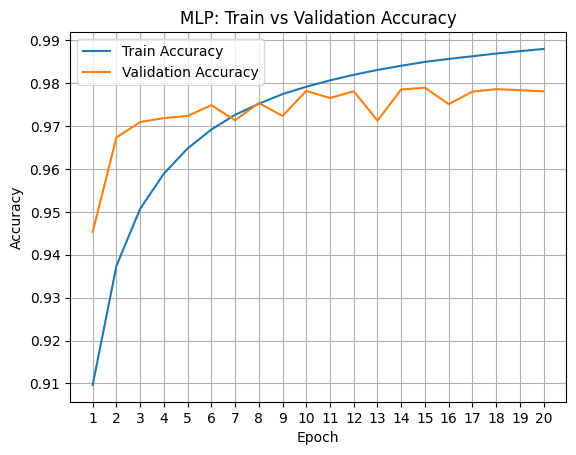

In [20]:
mlp_model = MLP()
trained_mlp, train_hist, val_hist = train_mlp(
    mlp_model, train_loader, val_loader, epochs=20, lr=1e-3
)
params_count = count_params(trained_mlp)
print("\n--- MLP Results ---")
print(f"\nNumber of Parameters in MLP: {params_count:,}")
val_acc  = evaluate_module(trained_mlp, val_loader)
test_acc = evaluate_module(trained_mlp, test_loader)
print("Final Val Acc:", val_acc)
print("Final Test Acc:", test_acc)

epochs = len(train_hist)
xs = range(1, epochs + 1)

plt.figure()
plt.plot(xs, train_hist, label="Train Accuracy")
plt.plot(xs, val_hist, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MLP: Train vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.xticks(range(1, epochs + 1))  
plt.show()

<font color="red">Answer the following questions:</font>

<ol>
  <li>
    Using your results, explain why this model outperforms the logistic-regression baseline.
    What key property of the architecture could be tied to the success?
    Cite specific evidence from your plots or errors.
    <br>
  </li>
<br>
  <li>
    Did you need all 20 epochs? If not, choose a stopping point from the validation curve, and justify it.
    Propose a concrete rule you would use next time to limit computation waste (spell out the metric and the trigger).
    <br>
  </li>


</ol>


<font color="red">
Answer for question 1:
The MLP model performs better because it learns non linear separation while logistic regression is only a linear classifier and MNIST digits aren't linearly separable, so logistic regression quickly hits a limit (around ~92–93% in my results).
The MLP model has two hidden layers with ReLU, which lets it learn shapes, curves, and combinations of pixel patterns. in my plots, the MLP’s validation accuracy reached ~97–98%, and its training loss went much lower than the logistic model. This shows it can fit the data better and build richer representations.

Answer for question 2:
No, we can see from the plot and the prints on epoch 10 the validation accuracy stopped improving,After that, it only fluctuated slightly but didn’t really get better.
A simple stopping rule I would use next time is: stop if validation accuracy dosn;t improve for 3 epochs, This would have ended training around epoch 13 and saved a lot of time while giving the same final accuracy.
</font>

### Exploring Initialization

Now, we’ll explore how **weight initialization** affects training dynamics and accuracy. In this section, you will expirement with different initilization methods, **changing only the initialization scheme** while keeping **everything else fixed**, including the model architecture, optimizer, data splits, number of epochs, batch size, etc.

<br>

In the previous code, you used PyTorch’s default: **Kaiming/He initialization**, which scales weights so that
$$
\mathrm{Var}(W_{ij}) \approx \frac{2}{\text{fan}_{in}}
$$
to help stabilize activations and gradients with ReLU layers.

In this section, you'll compare this baseline to four alternatives:
1. Zero initialization
2. Uniform $[0,1]$
3. Standard Normal: $\mathcal{N}(0,1)$
4. Xavier initialization

For each scheme, reinitialize <strong>all</strong> linear layers (weights and biases), train for 20 epochs using adam optimizer, and record validation accuracy per epoch and the final test accuracy. Then plot all validation-accuracy curves on one figure, report the final test accuracies for each method.

> Tip: Recreate a **fresh model** for each initialization; don’t re-use trained weights between runs.

In [8]:
# TODO: Implement
def init_zero(m):
    if isinstance(m, nn.Linear):
        init.zeros_(m.weight)
        if m.bias is not None:
            init.zeros_(m.bias)

def init_uniform_01(m):
    if isinstance(m, nn.Linear):
        init.uniform_(m.weight, a=0.0, b=1.0)
        if m.bias is not None:
            init.uniform_(m.bias, a=0.0, b=1.0)

def init_standard_normal(m):
    if isinstance(m, nn.Linear):
        init.normal_(m.weight, mean=0.0, std=1.0)
        if m.bias is not None:
            init.normal_(m.bias, mean=0.0, std=1.0)

def init_xavier(m):
    if isinstance(m, nn.Linear):
        init.xavier_uniform_(m.weight)
        if m.bias is not None:
            init.zeros_(m.bias)

In [14]:
kaiming_model = MLP()   # PyTorch already applies Kaiming init to Linear layers by default
trained_kaiming, train_hist_kaiming, val_hist_kaiming = train_mlp(
    kaiming_model, train_loader, val_loader, 20, 1e-3
)

zero_model = MLP()
zero_model.apply(init_zero)
trained_zero,train_hist_zero,val_hist_zero = train_mlp(zero_model,train_loader,val_loader,20,1e-3)

uniform_model = MLP()
uniform_model.apply(init_uniform_01)
trained_uniform,train_hist_uniform,val_hist_uniform = train_mlp(uniform_model,train_loader,val_loader,20,1e-3)

normal_model = MLP()
normal_model.apply(init_standard_normal)
trained_normal,train_hist_normal,val_hist_normal = train_mlp(normal_model,train_loader,val_loader,20,1e-3)

xavier_model = MLP()
xavier_model.apply(init_xavier)
trained_xavier,train_hist_xavier,val_hist_xavier = train_mlp(xavier_model,train_loader,val_loader,20,1e-3)

# Final validation & test accuracies for each initialization
kaiming_val_acc  = evaluate_module(trained_kaiming, val_loader)
kaiming_test_acc = evaluate_module(trained_kaiming, test_loader)

zero_val_acc   = evaluate_module(trained_zero,   val_loader)
zero_test_acc  = evaluate_module(trained_zero,   test_loader)

uniform_val_acc  = evaluate_module(trained_uniform, val_loader)
uniform_test_acc = evaluate_module(trained_uniform, test_loader)

normal_val_acc   = evaluate_module(trained_normal,  val_loader)
normal_test_acc  = evaluate_module(trained_normal,  test_loader)

xavier_val_acc   = evaluate_module(trained_xavier,  val_loader)
xavier_test_acc  = evaluate_module(trained_xavier,  test_loader)

Epoch 1/20, Train Acc: 0.9089, Val Acc: 0.9526, Loss: 0.1286
Epoch 2/20, Train Acc: 0.9369, Val Acc: 0.9640, Loss: 0.0652
Epoch 3/20, Train Acc: 0.9501, Val Acc: 0.9706, Loss: 0.0894
Epoch 4/20, Train Acc: 0.9586, Val Acc: 0.9723, Loss: 0.0978
Epoch 5/20, Train Acc: 0.9644, Val Acc: 0.9747, Loss: 0.0512
Epoch 6/20, Train Acc: 0.9686, Val Acc: 0.9756, Loss: 0.0698
Epoch 7/20, Train Acc: 0.9720, Val Acc: 0.9746, Loss: 0.0142
Epoch 8/20, Train Acc: 0.9746, Val Acc: 0.9737, Loss: 0.0352
Epoch 9/20, Train Acc: 0.9768, Val Acc: 0.9768, Loss: 0.0020
Epoch 10/20, Train Acc: 0.9787, Val Acc: 0.9765, Loss: 0.0036
Epoch 11/20, Train Acc: 0.9804, Val Acc: 0.9763, Loss: 0.0088
Epoch 12/20, Train Acc: 0.9816, Val Acc: 0.9728, Loss: 0.0406
Epoch 13/20, Train Acc: 0.9826, Val Acc: 0.9775, Loss: 0.0215
Epoch 14/20, Train Acc: 0.9836, Val Acc: 0.9756, Loss: 0.0097
Epoch 15/20, Train Acc: 0.9845, Val Acc: 0.9763, Loss: 0.0018
Epoch 16/20, Train Acc: 0.9853, Val Acc: 0.9783, Loss: 0.0062
Epoch 17/20, Trai

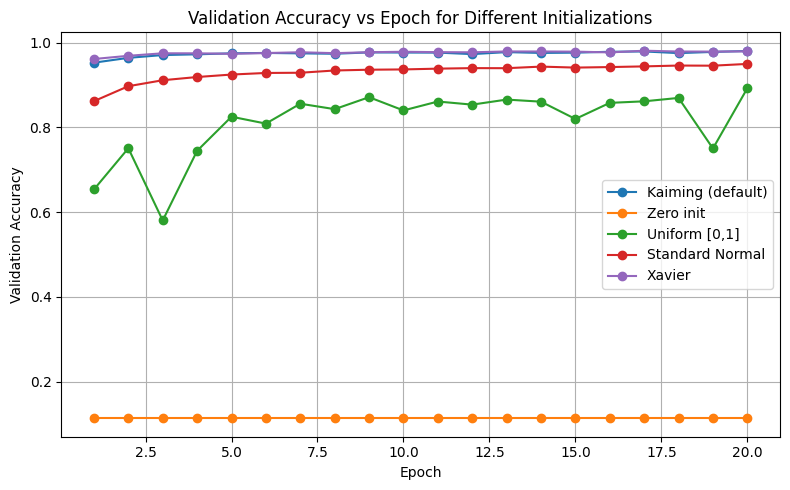

Kaiming (default) -> Val Acc: 0.9802, Test Acc: 0.9814
Zero init        -> Val Acc: 0.1133,   Test Acc: 0.1135
Uniform [0,1]    -> Val Acc: 0.8922, Test Acc: 0.8978
Std Normal       -> Val Acc: 0.9497,  Test Acc: 0.9514
Xavier           -> Val Acc: 0.9793,  Test Acc: 0.9800


In [15]:
epochs = range(1, len(val_hist_zero) + 1)

plt.figure(figsize=(8, 5))

plt.plot(epochs, val_hist_kaiming, marker='o', label='Kaiming (default)')
plt.plot(epochs, val_hist_zero,    marker='o', label='Zero init')
plt.plot(epochs, val_hist_uniform, marker='o', label='Uniform [0,1]')
plt.plot(epochs, val_hist_normal,  marker='o', label='Standard Normal')
plt.plot(epochs, val_hist_xavier,  marker='o', label='Xavier')

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy vs Epoch for Different Initializations')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Kaiming (default) -> Val Acc: {kaiming_val_acc:.4f}, Test Acc: {kaiming_test_acc:.4f}")
print(f"Zero init        -> Val Acc: {zero_val_acc:.4f},   Test Acc: {zero_test_acc:.4f}")
print(f"Uniform [0,1]    -> Val Acc: {uniform_val_acc:.4f}, Test Acc: {uniform_test_acc:.4f}")
print(f"Std Normal       -> Val Acc: {normal_val_acc:.4f},  Test Acc: {normal_test_acc:.4f}")
print(f"Xavier           -> Val Acc: {xavier_val_acc:.4f},  Test Acc: {xavier_test_acc:.4f}")

<font color="red">Answer the following question:</font>

Why does zero initialization cause training to fail, even though the optimizer still updates the weights?


<font color="red">Because it makes all the neurons start with the same weights and they get updated with the same gradients, this means they all update in the same way and basically stay clones of each other. When every neuron behaves the same, the layer can’t learn different features, so the network becomes too weak to actually learn the task. The optimizer still changes the numbers, but the model never breaks this symmetry, so learning doesn’t really happen.</font>

### Exploring Optimization Methods


Finally, we’ll explore how **different Optimization** methods affect training dynamics and accuracy. In this section, you will expirement with different optimizers, **changing only the optimization method** while keeping **everything else fixed**, including the model architecture, selecting the best initialization scheme you got earlier, data splits, number of epochs, batch size, etc.

<br>

Up to this point, you used the **Adam** optimizer. Here, you will experiment with alternative optimizers and compare their performance under the same settings.

In this section, you'll compare this baseline to three other alternatives:
1. Stochastic Gradient Descent (SGD)
2. RMSProp
3. Adagrad


As you did with initilization exploring, for each optimizer, create a **fresh model** and apply the **same fixed initialization** to all `nn.Linear` layers (weights & biases). Train the model for **20 epochs**. Plot all **validation-accuracy vs. epoch** curves on one figure and compare test accuracies.

> Tip: Recreate a **fresh model** for each initialization; don’t re-use trained weights between runs.

In [9]:
# TODO: Implement
def train_mlp_with_optimizer(model: nn.Module,
              train_loader,
              val_loader,
              epochs=20,
              lr=0.01,
              optimizer_name="adam"):
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(DEVICE)

    if optimizer_name.lower() == "adam":
        optimizer = optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name.lower() == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=lr)
    elif optimizer_name.lower() == "rmsprop":
        optimizer = optim.RMSprop(model.parameters(), lr=lr)
    elif optimizer_name.lower() == "adagrad":
        optimizer = optim.Adagrad(model.parameters(), lr=lr)
    else:
        raise ValueError(f"Unknown optimizer: {optimizer_name}")

    train_acc_history = []
    val_acc_history   = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = []

        train_correct = 0
        train_total   = 0

        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()
            logits = model(images)
            loss = F.cross_entropy(logits, labels)
            loss.backward()
            optimizer.step()

            epoch_loss.append(loss.item())

            preds = logits.argmax(dim=1)
            train_correct += (preds == labels).sum().item()
            train_total   += labels.size(0)

        train_acc = train_correct / train_total
        val_acc   = evaluate_module(model, val_loader)
        avg_loss  = sum(epoch_loss) / len(epoch_loss)

        train_acc_history.append(train_acc)
        val_acc_history.append(val_acc)

        print(
            f"[{optimizer_name.upper()}] "
            f"Epoch {epoch+1}/{epochs}, "
            f"Train Acc: {train_acc:.4f}, "
            f"Val Acc: {val_acc:.4f}, "
            f"Loss: {avg_loss:.4f}"
        )

    return model, train_acc_history, val_acc_history



In [16]:
def create_model_with_xavier():
    m = MLP()
    m.apply(init_xavier)  
    return m

epochs = 20
adam_lr = 1e-3
SGD_lr = 0.1
RMSprop_lr = 1e-3
Adagrad_lr = 1e-2

adam_model = create_model_with_xavier()
adam_model, train_adam, val_adam = train_mlp_with_optimizer(
    adam_model, train_loader, val_loader,
    epochs=epochs, lr=adam_lr, optimizer_name="adam"
)

sgd_model = create_model_with_xavier()
sgd_model, train_sgd, val_sgd = train_mlp_with_optimizer(
    sgd_model, train_loader, val_loader,
    epochs=epochs, lr=SGD_lr, optimizer_name="sgd"
)

rms_model = create_model_with_xavier()
rms_model, train_rms, val_rms = train_mlp_with_optimizer(
    rms_model, train_loader, val_loader,
    epochs=epochs, lr=RMSprop_lr, optimizer_name="rmsprop"
)

ada_model = create_model_with_xavier()
ada_model, train_ada, val_ada = train_mlp_with_optimizer(
    ada_model, train_loader, val_loader,
    epochs=epochs, lr=Adagrad_lr, optimizer_name="adagrad"
)

adam_val  = evaluate_module(adam_model,  val_loader)
adam_test = evaluate_module(adam_model,  test_loader)

sgd_val   = evaluate_module(sgd_model,   val_loader)
sgd_test  = evaluate_module(sgd_model,   test_loader)

rms_val   = evaluate_module(rms_model,   val_loader)
rms_test  = evaluate_module(rms_model,   test_loader)

ada_val   = evaluate_module(ada_model,   val_loader)
ada_test  = evaluate_module(ada_model,   test_loader)


[ADAM] Epoch 1/20, Train Acc: 0.9248, Val Acc: 0.9563, Loss: 0.2578
[ADAM] Epoch 2/20, Train Acc: 0.9720, Val Acc: 0.9689, Loss: 0.0921
[ADAM] Epoch 3/20, Train Acc: 0.9813, Val Acc: 0.9730, Loss: 0.0602
[ADAM] Epoch 4/20, Train Acc: 0.9868, Val Acc: 0.9709, Loss: 0.0408
[ADAM] Epoch 5/20, Train Acc: 0.9893, Val Acc: 0.9761, Loss: 0.0325
[ADAM] Epoch 6/20, Train Acc: 0.9924, Val Acc: 0.9763, Loss: 0.0238
[ADAM] Epoch 7/20, Train Acc: 0.9938, Val Acc: 0.9748, Loss: 0.0192
[ADAM] Epoch 8/20, Train Acc: 0.9944, Val Acc: 0.9748, Loss: 0.0164
[ADAM] Epoch 9/20, Train Acc: 0.9946, Val Acc: 0.9753, Loss: 0.0170
[ADAM] Epoch 10/20, Train Acc: 0.9954, Val Acc: 0.9748, Loss: 0.0138
[ADAM] Epoch 11/20, Train Acc: 0.9955, Val Acc: 0.9789, Loss: 0.0123
[ADAM] Epoch 12/20, Train Acc: 0.9972, Val Acc: 0.9768, Loss: 0.0088
[ADAM] Epoch 13/20, Train Acc: 0.9968, Val Acc: 0.9754, Loss: 0.0102
[ADAM] Epoch 14/20, Train Acc: 0.9958, Val Acc: 0.9742, Loss: 0.0137
[ADAM] Epoch 15/20, Train Acc: 0.9953, Val 

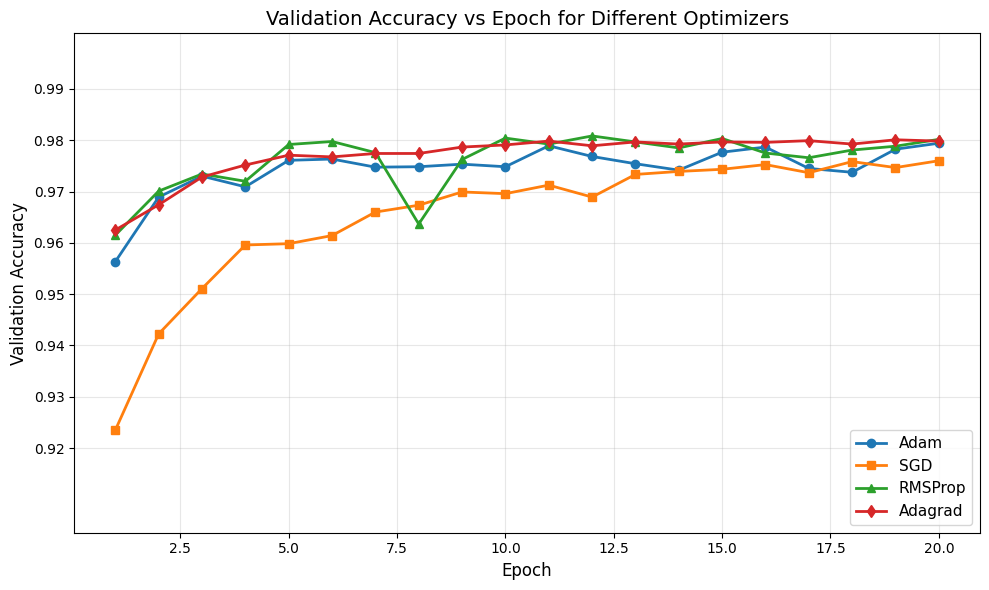

Adam    -> Val: 0.9794, Test: 0.9820
SGD     -> Val: 0.9760, Test: 0.9796
RMSProp -> Val: 0.9802, Test: 0.9799
Adagrad -> Val: 0.9798, Test: 0.9816


In [17]:
xs = range(1, epochs + 1)

plt.figure(figsize=(10, 6))
plt.plot(xs, val_adam, label="Adam",    marker='o', linewidth=2, markersize=6)
plt.plot(xs, val_sgd,  label="SGD",     marker='s', linewidth=2, markersize=6)
plt.plot(xs, val_rms,  label="RMSProp", marker='^', linewidth=2, markersize=6)
plt.plot(xs, val_ada,  label="Adagrad", marker='d', linewidth=2, markersize=6)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Validation Accuracy", fontsize=12)
plt.title("Validation Accuracy vs Epoch for Different Optimizers", fontsize=14)
plt.legend(fontsize=11, loc='lower right')
plt.grid(True, alpha=0.3)

min_acc = min(min(val_adam), min(val_sgd), min(val_rms), min(val_ada))
max_acc = max(max(val_adam), max(val_sgd), max(val_rms), max(val_ada))
plt.ylim([min_acc - 0.02, max_acc + 0.02])

plt.yticks(np.arange(np.floor(min_acc * 100) / 100, np.ceil(max_acc * 100) / 100 + 0.01, 0.01))

plt.tight_layout()
plt.show()

print(f"Adam    -> Val: {adam_val:.4f}, Test: {adam_test:.4f}")
print(f"SGD     -> Val: {sgd_val:.4f}, Test: {sgd_test:.4f}")
print(f"RMSProp -> Val: {rms_val:.4f}, Test: {rms_test:.4f}")
print(f"Adagrad -> Val: {ada_val:.4f}, Test: {ada_test:.4f}")

Consider the interaction between initialization and optimization:

- Combine the **best-performing initialization** with the **worst-performing optimizer**.
- Combine the **worst-performing initialization** with the **best-performing optimizer**.

Run both experiments and compare the learning dynamics.



In [11]:
# Implement
"""
According to the optimization plots adagrad works best here because its adaptive learning rates keep training stable and help the model reach consistently high accuracy.
also according to the initialization plots zero initialization performed worst so we will use it here as well.
"""
model_1 = MLP()
model_1.apply(init_zero)
model_1, train_hist_1, val_hist_1 = train_mlp_with_optimizer(
    model_1, train_loader, val_loader,
    epochs=20, lr=1e-2, optimizer_name="adagrad"
)
"""
According to the optimization plots sgd works the worst so we will use it here.
According to the initialization plots xavier initialization performed best so we will use it here as well.
"""
model_2 = MLP()
model_2.apply(init_xavier)
model_2, train_hist_2, val_hist_2 = train_mlp_with_optimizer(
    model_2, train_loader, val_loader,
    epochs=20, lr=0.1, optimizer_name="sgd"
)

[ADAGRAD] Epoch 1/20, Train Acc: 0.1112, Val Acc: 0.1133, Loss: 2.3018
[ADAGRAD] Epoch 2/20, Train Acc: 0.1121, Val Acc: 0.1133, Loss: 2.3014
[ADAGRAD] Epoch 3/20, Train Acc: 0.1121, Val Acc: 0.1133, Loss: 2.3013
[ADAGRAD] Epoch 4/20, Train Acc: 0.1121, Val Acc: 0.1133, Loss: 2.3013
[ADAGRAD] Epoch 5/20, Train Acc: 0.1121, Val Acc: 0.1133, Loss: 2.3013
[ADAGRAD] Epoch 6/20, Train Acc: 0.1121, Val Acc: 0.1133, Loss: 2.3013
[ADAGRAD] Epoch 7/20, Train Acc: 0.1121, Val Acc: 0.1133, Loss: 2.3013
[ADAGRAD] Epoch 8/20, Train Acc: 0.1121, Val Acc: 0.1133, Loss: 2.3013
[ADAGRAD] Epoch 9/20, Train Acc: 0.1121, Val Acc: 0.1133, Loss: 2.3013
[ADAGRAD] Epoch 10/20, Train Acc: 0.1121, Val Acc: 0.1133, Loss: 2.3013
[ADAGRAD] Epoch 11/20, Train Acc: 0.1121, Val Acc: 0.1133, Loss: 2.3013
[ADAGRAD] Epoch 12/20, Train Acc: 0.1121, Val Acc: 0.1133, Loss: 2.3013
[ADAGRAD] Epoch 13/20, Train Acc: 0.1121, Val Acc: 0.1133, Loss: 2.3013
[ADAGRAD] Epoch 14/20, Train Acc: 0.1121, Val Acc: 0.1133, Loss: 2.3013
[

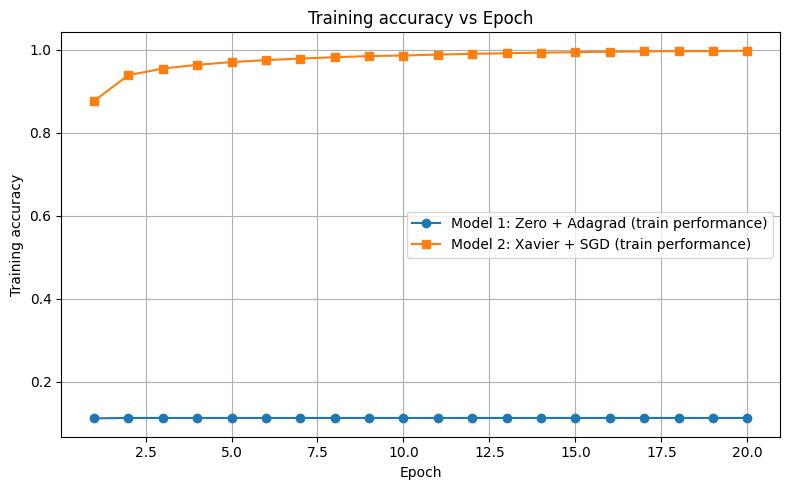

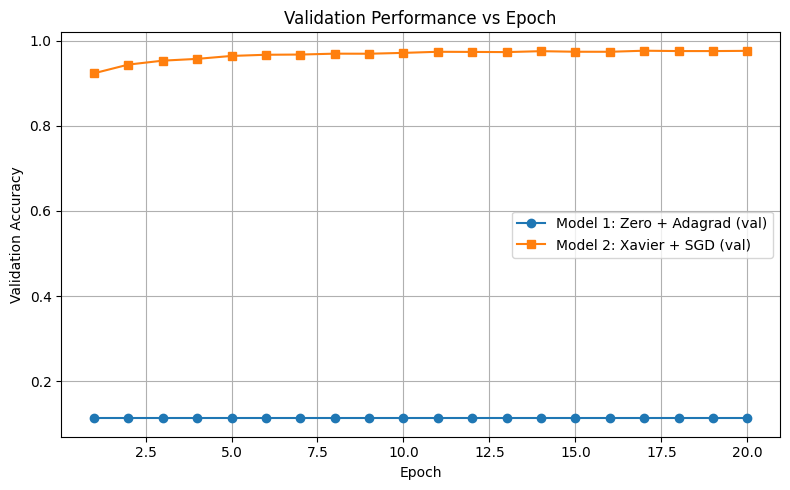

Model 1 (Zero + Adagrad): best val metric = 0.1133 at epoch 1
Model 2 (Xavier + SGD):      best val metric = 0.9762 at epoch 17


In [21]:
epochs_1 = np.arange(1, len(train_hist_1) + 1)
epochs_2 = np.arange(1, len(train_hist_2) + 1)

# 1) Training loss comparison
plt.figure(figsize=(8, 5))
plt.plot(epochs_1, train_hist_1, marker='o', label='Model 1: Zero + Adagrad (train performance)')
plt.plot(epochs_2, train_hist_2, marker='s', label='Model 2: Xavier + SGD (train performance)')
plt.xlabel('Epoch')
plt.ylabel('Training accuracy')
plt.title('Training accuracy vs Epoch')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 2) Validation accuracy (or loss) comparison
plt.figure(figsize=(8, 5))
plt.plot(epochs_1, val_hist_1, marker='o', label='Model 1: Zero + Adagrad (val)')
plt.plot(epochs_2, val_hist_2, marker='s', label='Model 2: Xavier + SGD (val)')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy' )  # or 'Validation Loss' if that’s what you stored
plt.title('Validation Performance vs Epoch')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 3) Print best validation performance for each model
best_val_1 = max(val_hist_1)
best_epoch_1 = np.argmax(val_hist_1) + 1

best_val_2 = max(val_hist_2)
best_epoch_2 = np.argmax(val_hist_2) + 1

print(f"Model 1 (Zero + Adagrad): best val metric = {best_val_1:.4f} at epoch {best_epoch_1}")
print(f"Model 2 (Xavier + SGD):      best val metric = {best_val_2:.4f} at epoch {best_epoch_2}")


## Question 2:  Multidimentional XOR and backpropagation

Given $ d $ bits $b=(b_1, b_2, ... , b_d) \in \{0, 1\}^d$, we define $$XOR(b) = Σ_{i=1}^db_i\ mod\ 2$$

In this question, you will train a feedforward neural network to model the multidimensional XOR problem.




The following function returns the labeled XOR "dataset" for any given $d$ (`dim`)

In [2]:
def XORData(dim):
  X = np.array(list(itertools.product([0, 1], repeat=dim)))
  Y = X.sum(axis=1)%2
  return X, Y

Implement the following:

1. A linear layer class:`Linear(torch.nn.Module)`\
• You should inherit from `torch.nn.Module`\
• You can not use `torch.nn.LinearLayer` or any other model implemented by PyTorch, only tensors. Wrap every tensor object with `torch.nn.Parameter` (for the optimizer).\
• Use `torch.randn` to initialize the parameter tensors (weights matrix and biases vector)\
• Implement the `forward` method according to the linear model $y = Wx + b$\
• The number of parameters should be defined by `in_features` and `out_features` \
• Make sure to enable gradient computation!

In [3]:
class Linear(nn.Module):
  def __init__(self, in_features, out_features):
    super().__init__()
    self.W = nn.Parameter(torch.randn(out_features, in_features))
    self.b = nn.Parameter(torch.randn(out_features))

  def forward(self, x):
    return x @ self.W.T + self.b

2. A feedforward neural network:`FFNet(torch.nn.module)`\
• Use the `Linear` class you implemented to construct a network with `in_features` input size, `out_features` output size, and one hidden layer with `hidden_size` neurons.\
• Use the sigmoid activation function on top of the hidden layer neurons.

In [4]:
class FFNet(nn.Module):
  def __init__(self, in_features, out_features, hidden_size):
    super().__init__()
    self.layer1 = Linear(in_features, hidden_size)
    self.layer2 = Linear(hidden_size, out_features)

  def forward(self, x):
    linear_part = self.layer1(x)
    h = torch.sigmoid(linear_part)
    return self.layer2(h)

### Exploring the hidden layer
In class we discussed the **Universal Approximation Theorem**. The following question will help us to understand how hard it is to find the optimal weight mentioned in the theorem.

You are given a basic training function:

In [5]:
loss_func = nn.MSELoss()

def train(net, X, Y, optimizer, epochs=300):
    steps = X.shape[0]
    losses = []
    for i in range(epochs):
        epoch_losses = []
        for j in range(steps):
            data_point = np.random.randint((X.shape[0]))
            x_var = torch.Tensor(X[data_point])
            y_var = torch.Tensor([Y[data_point]])
            optimizer.zero_grad()
            y_hat = net(x_var)
            loss = loss_func(y_hat, y_var)
            loss.backward()
            optimizer.step()
            epoch_losses.append(loss.detach())
        losses.append(np.mean(epoch_losses))
        if(i % 100 == 0):
            print("Epoch:{}, Loss:{}".format(i, loss.detach()))
    return losses
    

Using the code above, for each of the dimensions: $d = 2, 3, 4, 5$:
1. Create the corresponding dataset using `XORData`
2. Create models with different hidden layer sizes($1, 2, 3, ..., d,d+const, const*d,...$ etc.) and an optimizer for it using: `optimizer = optim.SGD(model.parameters(), lr=0.02, momentum=0.9)
`
3. Try to train the different networks on the dataset.
4. Plot the losses for different models on the same grid. Reflect on your findings.

Make sure to create a new `FFNet` and optimizer objects each time you call `train`.



Training model with input dim 2 and hidden size 1
Epoch:0, Loss:0.9901068806648254
Epoch:100, Loss:0.2737163305282593
Epoch:200, Loss:0.4395492970943451

Training model with input dim 2 and hidden size 2
Epoch:0, Loss:0.276210755109787
Epoch:100, Loss:0.03195374831557274
Epoch:200, Loss:0.5533909201622009

Training model with input dim 2 and hidden size 3
Epoch:0, Loss:0.189738467335701
Epoch:100, Loss:0.25738590955734253
Epoch:200, Loss:0.4576452672481537

Training model with input dim 2 and hidden size 2
Epoch:0, Loss:0.2373955100774765
Epoch:100, Loss:0.30011704564094543
Epoch:200, Loss:0.17458732426166534

Training model with input dim 2 and hidden size 5
Epoch:0, Loss:0.25170329213142395
Epoch:100, Loss:0.09233535826206207
Epoch:200, Loss:7.93530562077649e-05

Training model with input dim 2 and hidden size 6
Epoch:0, Loss:0.44618991017341614
Epoch:100, Loss:0.013443639501929283
Epoch:200, Loss:1.1166392141603865e-05


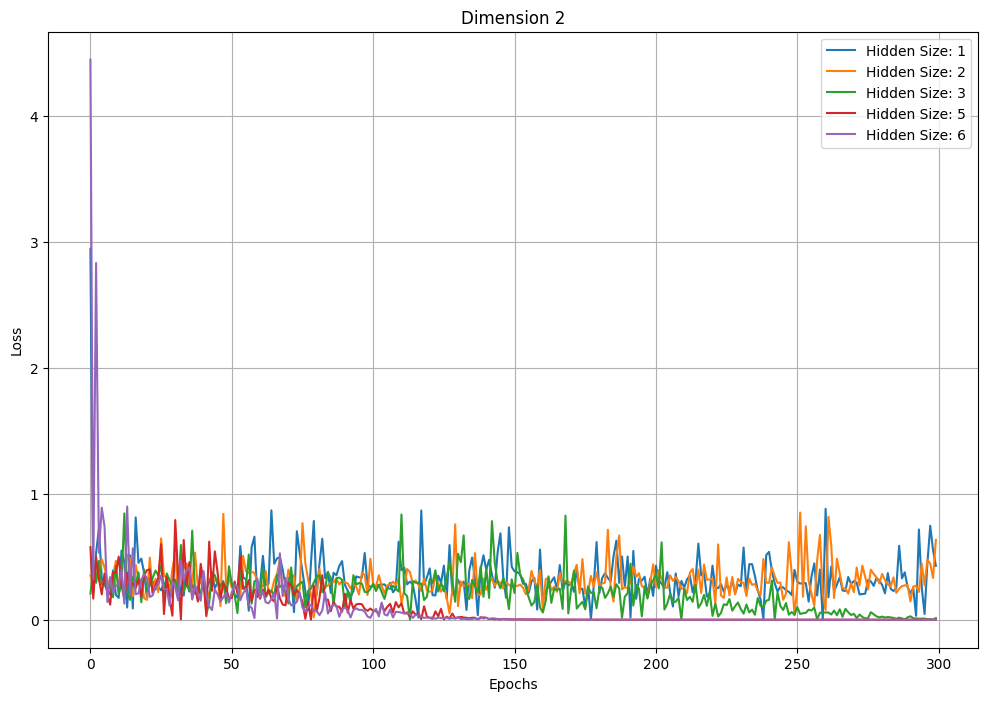


Training model with input dim 3 and hidden size 1
Epoch:0, Loss:0.42699098587036133
Epoch:100, Loss:0.06999917328357697
Epoch:200, Loss:0.3978303074836731

Training model with input dim 3 and hidden size 2
Epoch:0, Loss:0.14713020622730255
Epoch:100, Loss:0.5070388913154602
Epoch:200, Loss:0.13000307977199554

Training model with input dim 3 and hidden size 3
Epoch:0, Loss:0.7233331799507141
Epoch:100, Loss:0.14925625920295715
Epoch:200, Loss:0.5256105065345764

Training model with input dim 3 and hidden size 3
Epoch:0, Loss:0.8837245106697083
Epoch:100, Loss:0.08927110582590103
Epoch:200, Loss:0.0002653585688676685

Training model with input dim 3 and hidden size 6
Epoch:0, Loss:0.16361673176288605
Epoch:100, Loss:0.8807322382926941
Epoch:200, Loss:0.7127002477645874

Training model with input dim 3 and hidden size 9
Epoch:0, Loss:0.005281446035951376
Epoch:100, Loss:0.08062010258436203
Epoch:200, Loss:0.00019010851974599063


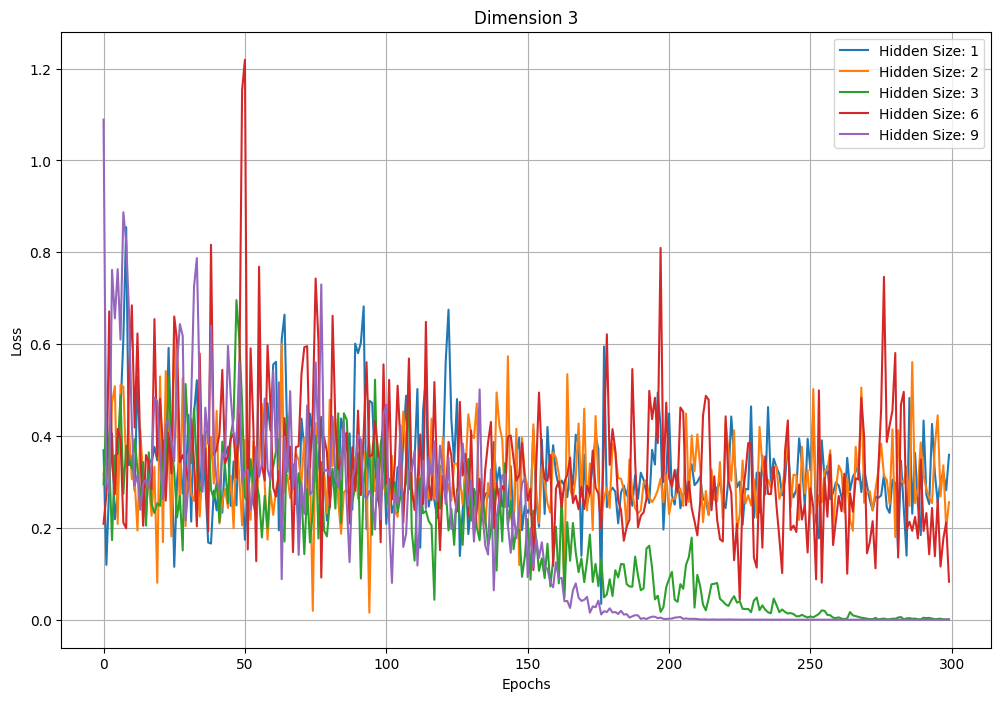


Training model with input dim 4 and hidden size 1
Epoch:0, Loss:0.04878168925642967
Epoch:100, Loss:0.5052850246429443
Epoch:200, Loss:0.2597905099391937

Training model with input dim 4 and hidden size 2
Epoch:0, Loss:0.9070490002632141
Epoch:100, Loss:0.6502609848976135
Epoch:200, Loss:0.4261484146118164

Training model with input dim 4 and hidden size 3
Epoch:0, Loss:0.2620311975479126
Epoch:100, Loss:0.5387235879898071
Epoch:200, Loss:0.6523569226264954

Training model with input dim 4 and hidden size 4
Epoch:0, Loss:1.6354410648345947
Epoch:100, Loss:0.3206982910633087
Epoch:200, Loss:0.3593858778476715

Training model with input dim 4 and hidden size 7
Epoch:0, Loss:0.02931390143930912
Epoch:100, Loss:0.4073403775691986
Epoch:200, Loss:0.5784854888916016

Training model with input dim 4 and hidden size 12
Epoch:0, Loss:0.03653160482645035
Epoch:100, Loss:0.3334600329399109
Epoch:200, Loss:0.18277403712272644


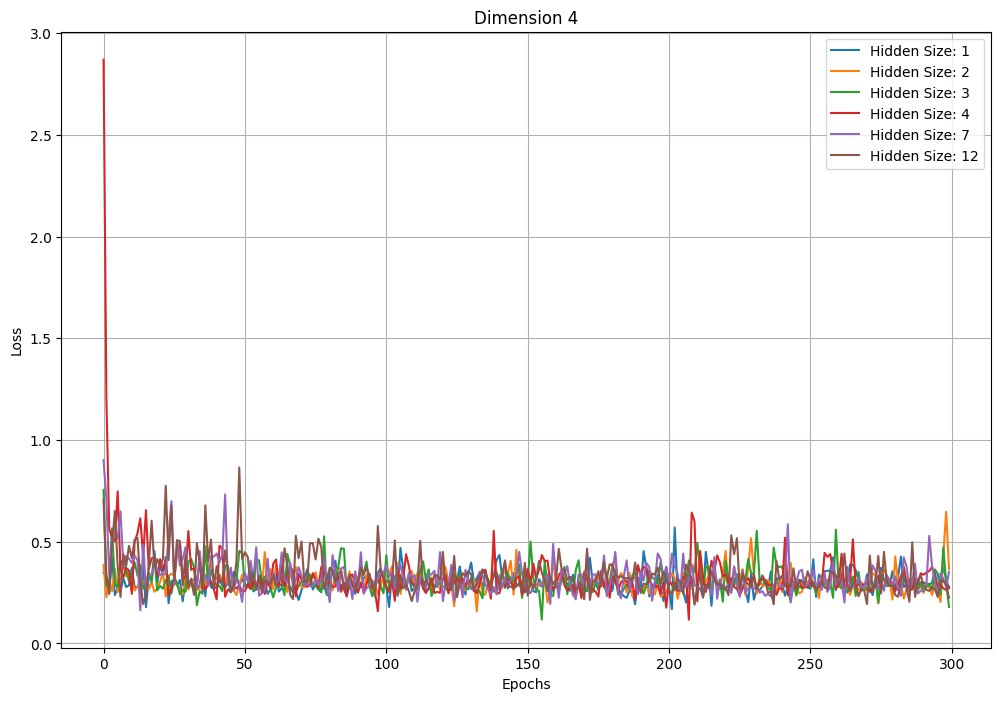


Training model with input dim 5 and hidden size 1
Epoch:0, Loss:0.4360344409942627
Epoch:100, Loss:0.7294434309005737
Epoch:200, Loss:0.5375677347183228

Training model with input dim 5 and hidden size 2
Epoch:0, Loss:0.29448309540748596
Epoch:100, Loss:0.14920279383659363
Epoch:200, Loss:0.2528650164604187

Training model with input dim 5 and hidden size 3
Epoch:0, Loss:0.34509360790252686
Epoch:100, Loss:0.5542984008789062
Epoch:200, Loss:0.530474066734314

Training model with input dim 5 and hidden size 5
Epoch:0, Loss:0.39197590947151184
Epoch:100, Loss:0.006030448712408543
Epoch:200, Loss:0.5637829899787903

Training model with input dim 5 and hidden size 8
Epoch:0, Loss:0.45123279094696045
Epoch:100, Loss:0.2653927505016327
Epoch:200, Loss:0.24821841716766357

Training model with input dim 5 and hidden size 15
Epoch:0, Loss:0.04000500962138176
Epoch:100, Loss:0.36235857009887695
Epoch:200, Loss:0.13116878271102905


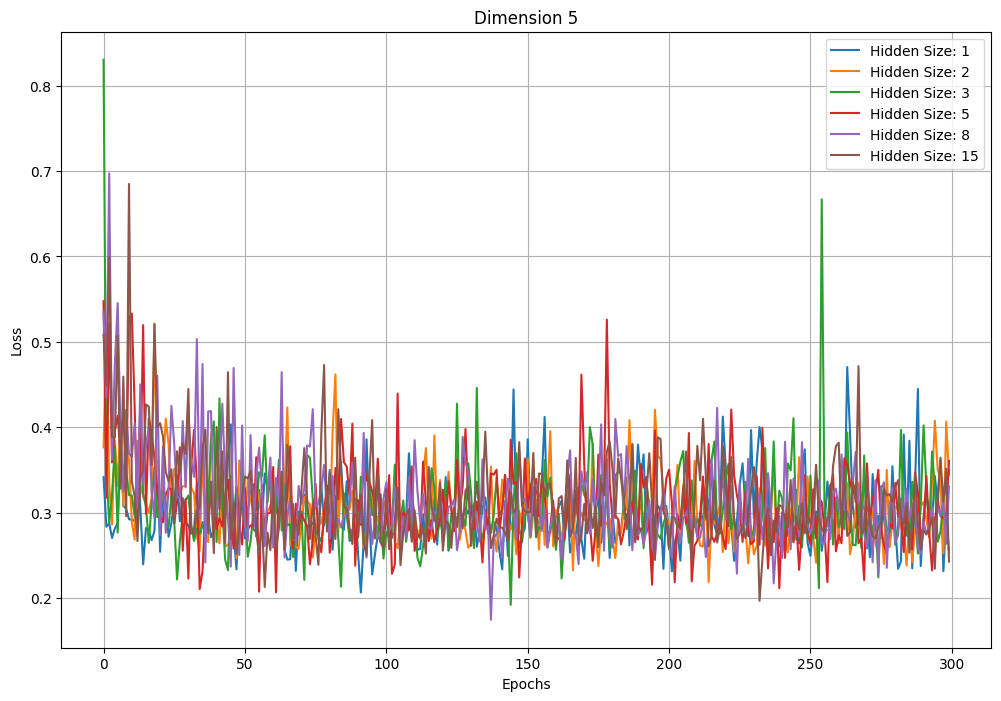

In [11]:
dims = [2, 3, 4, 5]
constant = 3
lr = 0.02
momentum = 0.9
num_epochs = 300
for d in dims:
    X, Y = XORData(d)   # XOR Dataset
    hidden_sizes = [1, 2, 3, d, d+constant, d*constant]
    all_losses = {}
    for hidden_size in hidden_sizes:
        print(f"\nTraining model with input dim {d} and hidden size {hidden_size}")
        model = FFNet(in_features=d, out_features=1, hidden_size=hidden_size)
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum)
        losses = train(model, X, Y, optimizer, epochs=num_epochs)
        all_losses[hidden_size] = losses

    # Plotting
    plt.figure(figsize=(12, 8))
    for hidden_size, losses in all_losses.items():
        plt.plot(losses, label=f'Hidden Size: {hidden_size}')
    plt.title(f'Dimension {d}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()
    plt.show()
    


<font color="red">**Answer the following questions:** </font>

1. For which dimensions were you able to reach a model that converges (loss value is geting close to 0)?
<font color="red">  

As we can see in the plots:
In Dimension 2 all models with hidden_size>2 got successfully converged.
In dimenstion 3, only the model with hidden size equal to 3 and 9 got converged.
In both dimenstions 4 and 5 none of the models got converged.


</font>

2. What is the number of hidden neurons in that network and how did you find it?


<font color="red">  
In Dimension 2: The minimum number of hidden neurons required for convergence was 3.
In Dimenstion 3: Only the network with 3 and 9 hidden neurons  achieved convergence.

How I found it: I  tested different hidden layer sizes using the formula hidden_sizes = [1, 2, 3, d, d+constant, d*constant] where constant=3.  and the ones who achieved convergence is the ones who got close to loss 0.



</font>

3. What results did you expect and how does it differ from the results you achieved?


<font color="red">  

I expected that adding more hidden neurons would help the model learn XOR for all dimensions, including dimensions 4 and 5. But the results show that no configuration worked for dimensions 4 and 5 (even with 15 neurons for dimension 5).

Why this happened:
1. Higher dimensions make the problem harder for the optimizer to solve in 300 epochs.
2. The learning rate (0.02) and momentum (0.9) might not work well for higher dimensions.
3. The Universal Approximation Theorem says a solution exists, but it doesn't mean we can find it easily. With random starting weights and limited training time, the optimizer struggles to find the right solution.


</font>


### Backpropagation

The following part will focus on the computaion of gradients with respect to the model parameters, aimed at understanding the functioning of `loss.backward()`.

Implement the function:`calc_gradients(net, x, loss)` with the following instructions:

- Input: instance of `FFNet` with a hidden layer of size 2, input of size 2 and output of size 1, input vector `x` and `loss` value.

- Output: One dimensional tensor with the gradients of the loss w.r.t each of the parameters, ordered as the corresponding parameters order `net.parameters()` returns (if we would flatten it's output).

1. Compute (by hand) the derivatives w.r.t the second linear layer parameters.
2. Use the chain rule to compute (by hand) the derivatives w.r.t the first linear layer parameters.
3. Implement the final form computations per parameter.
4. Order the gradients as described above.


In [12]:
def calc_gradients(net, x, y_var, y_hat, loss):
  
  # Extract parameters (weights and biases)
  W1 = net.layer1.W 
  b1 = net.layer1.b 
  W2 = net.layer2.W  
  b2 = net.layer2.b
  
  # Forward pass values needed for backprop
  z1 = W1 @ x + b1          
  h = torch.sigmoid(z1)      
  
  #  Backpropagation
  
  dL_dyhat = 2 * (y_hat - y_var) 
  
  dL_dW2 = dL_dyhat * h   
  dL_dW2 = dL_dW2.view(1, 2)
  
  dL_db2 = dL_dyhat  
  
  dL_dh = dL_dyhat * W2     
  dL_dh = dL_dh.view(-1)     
 
  sigmoid_grad = h * (1 - h) 
  dL_dz1 = dL_dh * sigmoid_grad  
  
  dL_dW1 = torch.outer(dL_dz1, x) 
  
  dL_db1 = dL_dz1
  
  # Flatten gradients in correct parameter order
  gradients = torch.cat([
      dL_dW1.view(-1),  
      dL_db1.view(-1), 
      dL_dW2.view(-1),  
      dL_db2.view(-1)   
  ])
  
  return gradients


Run the following cell to check the correctness of your computation:

In [13]:
def equal_gradients(net, x, y_var, y_hat, loss):
  grads = []
  for param in net.parameters():
    grads.append(param.grad.view(-1))
  grads = torch.cat(grads)
  return True if torch.sum(grads - calc_gradients(net, x, y_var, y_hat, loss)).round() == 0 else False # Added round because results were very close but not identical

def train_and_compare(net, X, Y, epochs=100):
  steps = X.shape[0]
  for i in range(epochs):
      for j in range(steps):
          data_point = np.random.randint(X.shape[0])
          x_var = torch.Tensor(X[data_point])
          y_var = torch.Tensor([Y[data_point]])
          optimizer.zero_grad()
          y_hat = net(x_var)
          loss = loss_func(y_hat, y_var)
          loss.backward()
          if not equal_gradients(net, x_var, y_var, y_hat, loss.item()):
            print("Wrong gradients computation!")
            return
          optimizer.step()
  print("Correct gradients computation!")

model = FFNet(2, 1, 2)
optimizer = optim.SGD(model.parameters(), lr=0.02, momentum=0.9)
X, Y = XORData(2)


train_and_compare(model, X, Y)

Correct gradients computation!
